<a href="https://colab.research.google.com/github/nirajsingh916262-debug/rabtech-task-2/blob/main/RabTech_Task_3_Statistical_Analysis_ipynbynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

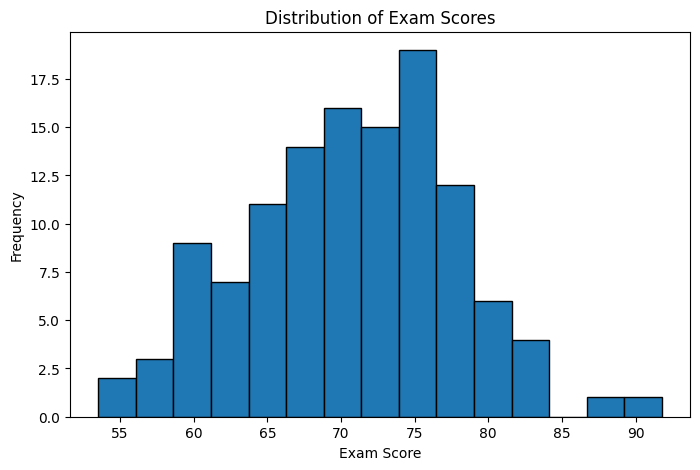

Shapiro-Wilk Test
Statistic: 0.993
P-value: 0.8147

Kolmogorov-Smirnov Test
Statistic: 0.0415
P-value: 0.9804
Two-Sample Welch t-test
Statistic: -2.2947
P-value: 0.0236

Mann-Whitney U Test
Statistic: 1385.0
P-value: 0.0296
One-way ANOVA
F-statistic: 32.7784
P-value: 0.0

Tukey HSD
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
 Active     Blended  -4.2353 0.0038  -7.2936  -1.177   True
 Active Traditional -10.3729    0.0 -13.4311 -7.3146   True
Blended Traditional  -6.1376    0.0  -9.1958 -3.0793   True
-----------------------------------------------------------
Two-way ANOVA
                                         sum_sq     df          F  \
C(study_method)                     2176.048403    2.0  34.263917   
C(training_format)                   258.852206    1.0   8.151740   
C(study_method):C(training_format)     4.786442    2.0   0.075367   
Residua

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)
n = 40

methods = np.repeat(
    ['Traditional', 'Blended', 'Active'], n
)

formats = np.tile(
    np.repeat(['Online', 'Classroom'], n//2), 3
)

effects = {
    'Traditional': 0,
    'Blended': 5,
    'Active': 9
}

format_effect = {
    'Online': 0,
    'Classroom': 3
}

scores = [
    65 + effects[m] + format_effect[f] + np.random.normal(0, 6)
    for m, f in zip(methods, formats)
]

df = pd.DataFrame({
    'study_method': methods,
    'training_format': formats,
    'exam_score': np.clip(scores, 0, 100)
})

df.head()
plt.figure(figsize=(8,5))

plt.hist(df['exam_score'], bins=15, edgecolor='black')

plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.title('Distribution of Exam Scores')

plt.show()

x = df['exam_score']

# Shapiro-Wilk test
shapiro = stats.shapiro(x)

# Kolmogorov-Smirnov test
ks = stats.kstest(
    (x - x.mean()) / x.std(),
    'norm'
)

print("Shapiro-Wilk Test")
print("Statistic:", round(shapiro.statistic, 4))
print("P-value:", round(shapiro.pvalue, 4))

print("\nKolmogorov-Smirnov Test")
print("Statistic:", round(ks.statistic, 4))
print("P-value:", round(ks.pvalue, 4))

online = df[df['training_format'] == 'Online']['exam_score']
classroom = df[df['training_format'] == 'Classroom']['exam_score']

# Welch's two-sample t-test
t_test = stats.ttest_ind(
    online,
    classroom,
    equal_var=False
)

# Mann-Whitney U test
mann_whitney = stats.mannwhitneyu(
    online,
    classroom,
    alternative='two-sided'
)

print("Two-Sample Welch t-test")
print("Statistic:", round(t_test.statistic, 4))
print("P-value:", round(t_test.pvalue, 4))

print("\nMann-Whitney U Test")
print("Statistic:", round(mann_whitney.statistic, 4))
print("P-value:", round(mann_whitney.pvalue, 4))
groups = [
    group['exam_score'].values
    for _, group in df.groupby('study_method')
]

anova = stats.f_oneway(*groups)

print("One-way ANOVA")
print("F-statistic:", round(anova.statistic, 4))
print("P-value:", round(anova.pvalue, 4))

print("\nTukey HSD")
tukey = pairwise_tukeyhsd(
    df['exam_score'],
    df['study_method'],
    alpha=0.05
)

print(tukey)
# Two-way ANOVA

model = ols(
    'exam_score ~ C(study_method) * C(training_format)',
    data=df
).fit()

two_way_anova = sm.stats.anova_lm(model, typ=2)

print("Two-way ANOVA")
print(two_way_anova)
print("FINAL FINDINGS")
print("=" * 50)

print("1. Normality tests were performed using Shapiro-Wilk and")
print("   Kolmogorov-Smirnov tests.")

print("\n2. Online and Classroom groups were compared using")
print("   Welch's two-sample t-test and Mann-Whitney U test.")

print("\n3. Differences among Traditional, Blended and Active")
print("   study methods were tested using one-way ANOVA.")
print("   Tukey HSD was used for pairwise comparisons.")

print("\n4. The effects of study method, training format and")
print("   their interaction were examined using two-way ANOVA.")

print("\n5. Statistical significance was assessed at alpha = 0.05.")

print("\nNote: This analysis uses a synthetic dataset for")
print("demonstration and reproducibility.")

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['exam_score'], bins=15, edgecolor='black')

plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.title('Distribution of Exam Scores')

plt.show()